## **<font color="red">Custom Polynomial Regression</font>**

Linear Regression Accuracy: 0.0158
Sklearn Polynomial (degree 2) Accuracy: 0.3735
Custom Polynomial (degree 2) Accuracy: 0.3735

Custom model polynomial: -16.03 + 1.257*x + 1.147*x^2

Sklearn polynomial coefficients (intercept, coef_x, coef_x2):
Intercept: -16.029, Coefs: [0.         1.25668284 1.14749977]


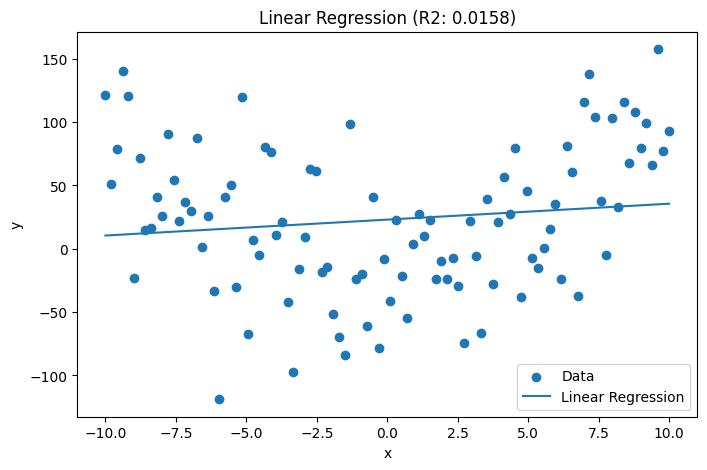

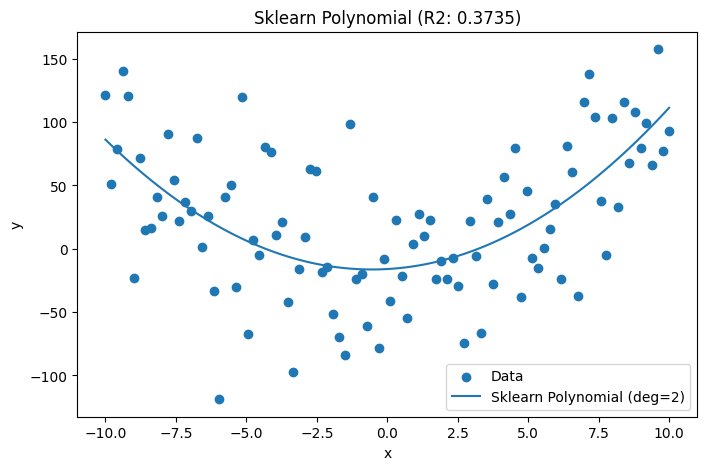

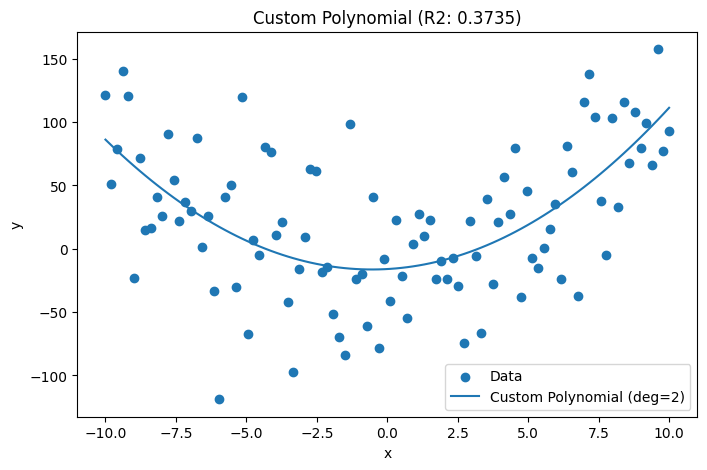


Done. The custom PolynomialRegressor fits using a design (Vandermonde) matrix and pseudo-inverse.


In [1]:
# Creating and demonstrating a custom PolynomialRegressor class
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

# Custom Polynomial Regressor (uses Vandermonde/design matrix + pseudo-inverse)
class PolynomialRegressor:
    def __init__(self, degree=2, fit_intercept=True, reg_lambda=0.0):
        """
        degree: polynomial degree (int)
        fit_intercept: include intercept (bool)
        reg_lambda: L2 regularization strength (float, 0 = no regularization)
        """
        self.degree = int(degree)
        self.fit_intercept = bool(fit_intercept)
        self.reg_lambda = float(reg_lambda)
        self.coef_ = None  # coefficients excluding intercept (highest -> lowest if using np.vander)
        self.intercept_ = 0.0

    def _design_matrix(self, X):
        """
        Build design matrix for input X.
        X can be shape (n,) or (n,1) or (n,).
        Returns shape (n, M) where M = degree+1 (including intercept column if fit_intercept True)
        Columns are [1, x, x^2, ..., x^degree] if fit_intercept True
        """
        X = np.asarray(X).reshape(-1)
        # powers from 0..degree
        powers = np.arange(0, self.degree + 1)
        # shape (n, degree+1)
        DM = np.vander(X, N=self.degree + 1, increasing=True)  # columns [1, x, x^2,...]
        if not self.fit_intercept:
            # if no intercept, drop column of ones (power 0)
            DM = DM[:, 1:]
        return DM

    def fit(self, X, y):
        """
        Fit using normal equation with pseudo-inverse and optional L2 regularization.
        """
        X = np.asarray(X)
        y = np.asarray(y).reshape(-1)
        DM = self._design_matrix(X)  # (n, m)
        # Regularization: add lambda*I to X^T X (do not regularize intercept if present)
        m = DM.shape[1]
        XtX = DM.T.dot(DM)
        if self.reg_lambda and self.reg_lambda > 0:
            reg = self.reg_lambda * np.eye(m)
            if self.fit_intercept:
                # do not regularize intercept (first column)
                reg[0, 0] = 0.0
            XtX = XtX + reg
        # Solve for weights using pseudo-inverse for stability
        w = np.linalg.pinv(XtX).dot(DM.T).dot(y)
        if self.fit_intercept:
            self.intercept_ = float(w[0])
            self.coef_ = np.array(w[1:])  # coef_ for x^1 ... x^degree
        else:
            self.intercept_ = 0.0
            self.coef_ = np.array(w)  # corresponds to x^1 ... x^degree
        return self

    def predict(self, X):
        X = np.asarray(X)
        DM = self._design_matrix(X)
        if self.fit_intercept:
            # build weight vector [intercept, coef_...]
            w = np.concatenate(([self.intercept_], self.coef_))
        else:
            w = self.coef_
        y_pred = DM.dot(w)
        return y_pred

    def score(self, X, y):
        y_pred = self.predict(X)
        return r2_score(y, y_pred)

    def as_polynomial_string(self):
        """
        Return human-readable polynomial string, highest to lowest power.
        """
        terms = []
        if self.fit_intercept:
            # intercept term
            if abs(self.intercept_) > 1e-12:
                terms.append(f"{self.intercept_:.4g}")
        for p, c in enumerate(self.coef_, start=1):
            if abs(c) < 1e-12:
                continue
            if p == 1:
                terms.append(f"{c:.4g}*x")
            else:
                terms.append(f"{c:.4g}*x^{p}")
        if not terms:
            return "0"
        return " + ".join(terms)

# -------------------------
# Data (same as user provided)
np.random.seed(0)
x = np.linspace(-10, 10, 100)
y = 3 + 2 * x + 0.5 * x**2 + np.random.normal(0, 50, 100)
x_col = x[:, np.newaxis]

# Linear Regression (sklearn)
model_linear = LinearRegression()
model_linear.fit(x_col, y)
y_pred_linear = model_linear.predict(x_col)
accuracy_linear = r2_score(y, y_pred_linear)
print(f"Linear Regression Accuracy: {accuracy_linear:.4f}")

# Polynomial Regression (sklearn pipeline degree 2)
model_poly_sklearn = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
model_poly_sklearn.fit(x_col, y)
y_pred_poly_sklearn = model_poly_sklearn.predict(x_col)
accuracy_poly_sklearn = r2_score(y, y_pred_poly_sklearn)
print(f"Sklearn Polynomial (degree 2) Accuracy: {accuracy_poly_sklearn:.4f}")

# Custom Polynomial Regressor (degree 2)
model_poly_custom = PolynomialRegressor(degree=2, fit_intercept=True, reg_lambda=0.0)
model_poly_custom.fit(x_col, y)
y_pred_poly_custom = model_poly_custom.predict(x_col)
accuracy_poly_custom = model_poly_custom.score(x_col, y)
print(f"Custom Polynomial (degree 2) Accuracy: {accuracy_poly_custom:.4f}")
print("\nCustom model polynomial:", model_poly_custom.as_polynomial_string())

# Compare coefficients with sklearn (sklearn's LinearRegression stores coef_ for transformed features)
# Extract sklearn coefficients (after PolynomialFeatures)
lin = model_poly_sklearn.named_steps['linearregression']
# PolynomialFeatures with include_bias=True creates columns [1, x, x^2]
sk_intercept = lin.intercept_
sk_coefs = lin.coef_  # corresponds to [bias_term, x, x^2] if fit_intercept True
print("\nSklearn polynomial coefficients (intercept, coef_x, coef_x2):")
print(f"Intercept: {sk_intercept:.6g}, Coefs: {sk_coefs}")

# -------------------------
# Visualization
# Requirement: one chart per figure (no subplots)
# 1) Scatter + Linear fit
plt.figure(figsize=(8,5))
plt.scatter(x, y, label="Data")
plt.plot(x, y_pred_linear, label="Linear Regression")
plt.title(f"Linear Regression (R2: {accuracy_linear:.4f})")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# 2) Scatter + Sklearn polynomial fit
plt.figure(figsize=(8,5))
plt.scatter(x, y, label="Data")
plt.plot(x, y_pred_poly_sklearn, label="Sklearn Polynomial (deg=2)")
plt.title(f"Sklearn Polynomial (R2: {accuracy_poly_sklearn:.4f})")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# 3) Scatter + Custom polynomial fit
plt.figure(figsize=(8,5))
plt.scatter(x, y, label="Data")
plt.plot(x, y_pred_poly_custom, label="Custom Polynomial (deg=2)")
plt.title(f"Custom Polynomial (R2: {accuracy_poly_custom:.4f})")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# End of demo
print("\nDone. The custom PolynomialRegressor fits using a design (Vandermonde) matrix and pseudo-inverse.")



## **<font color="green">Generate a Vandermonde matrix</font>**

In [2]:
x = np.array([1, 2, 3, 4, 5])
N = 8
np.vander(x, N)

array([[    1,     1,     1,     1,     1,     1,     1,     1],
       [  128,    64,    32,    16,     8,     4,     2,     1],
       [ 2187,   729,   243,    81,    27,     9,     3,     1],
       [16384,  4096,  1024,   256,    64,    16,     4,     1],
       [78125, 15625,  3125,   625,   125,    25,     5,     1]])

In [3]:
x = np.array([1, 2, 3, 4, 5])
N = 7
np.vander(x, N, increasing=True)

array([[    1,     1,     1,     1,     1,     1,     1],
       [    1,     2,     4,     8,    16,    32,    64],
       [    1,     3,     9,    27,    81,   243,   729],
       [    1,     4,    16,    64,   256,  1024,  4096],
       [    1,     5,    25,   125,   625,  3125, 15625]])

In [4]:
import numpy as np

x = np.array([[1, 2, 3, 4, 5],
              [5, 6, 7, 8, 9]])
N = 5

vander_matrices = np.array([np.vander(row, N, increasing=True) for row in x])
print(vander_matrices)


[[[   1    1    1    1    1]
  [   1    2    4    8   16]
  [   1    3    9   27   81]
  [   1    4   16   64  256]
  [   1    5   25  125  625]]

 [[   1    5   25  125  625]
  [   1    6   36  216 1296]
  [   1    7   49  343 2401]
  [   1    8   64  512 4096]
  [   1    9   81  729 6561]]]
